Mubarak ho! Data load ho gaya hai.

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3     

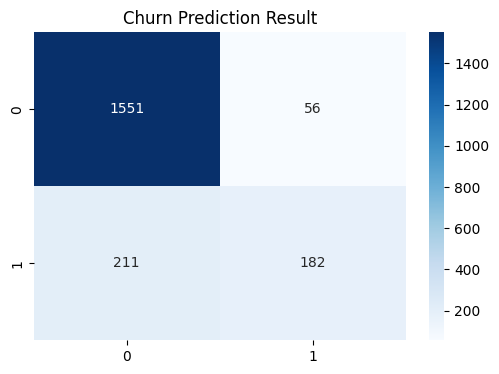

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Data Load karna
df = None # Initialize df to None
try:
    df = pd.read_csv('/Churn_Modelling.csv') # Path updated here
    print("Mubarak ho! Data load ho gaya hai.\n")
    print(df.head()) # Shuruat ki 5 rows dekhne ke liye
except Exception as e:
    print(f"Error: File nahi mili. Please left side mein 'Churn_Modelling.csv' upload karein. Details: {e}")

# Only proceed if df was successfully loaded
if df is not None:
    # 2. Data Cleaning
    # फालतू columns hatana
    df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

    # Text ko numbers mein badalna
    le = LabelEncoder()
    df['Gender'] = le.fit_transform(df['Gender'])
    df = pd.get_dummies(df, columns=['Geography'], drop_first=True)

    # 3. Features aur Target alag karna
    X = df.drop('Exited', axis=1)
    y = df['Exited']

    # 4. Train aur Test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 5. Scaling
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_test = scaler.transform(X_test)

    # 6. Model Training
    model = RandomForestClassifier(n_estimators=100, random_state=42)
    model.fit(X_train, y_train)

    # 7. Result Check karna
    y_pred = model.predict(X_test)
    print(f"\nModel Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")

    # 8. Graph banana (Visualisation)
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title('Churn Prediction Result')
    plt.show()